# 04a – Exploration des catégories socio-professionnelles (INSEE 2022)
 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

**Plan** : Importation → Contrôle → Nettoyage → Inspection → Visualisation

### Importation des données

In [2]:
csp = pd.read_excel(
    '../data/raw/Socio Eco/insee_csp_2022.xlsx',
    sheet_name='DEP',     # onglet des départements
    header=3,             # les noms de colonnes sont en ligne 4
    dtype={0: str}        # code département lu comme du texte
)

print(csp.shape)   # (taille csp)
csp.head()         

(104, 10)


,Unnamed: 0,Unnamed: 1,Part des agriculteurs exploitants (en %),"Part des artisans, commerçants et chefs d'entreprises (en %)",Part des cadres et professions intellectuelles supérieures (en %),Part des professions intermédiaires (en %),Part des employés (en %),Part des ouvriers (en %),Part des retraités (en %),Part des autres personnes sans activité professionnelle (en %)
0,01,Ain,0.6,4.1,10.0,16.6,15.5,14.2,26.0,12.9
1,02,Aisne,1.0,2.7,4.8,12.4,16.0,16.5,30.0,16.6
2,03,Allier,1.6,3.3,4.9,11.3,15.2,13.0,37.6,13.2
3,04,Alpes-de-Haute-Provence,1.5,5.4,6.6,13.3,14.4,10.5,34.9,13.5
4,05,Hautes-Alpes,1.6,5.4,5.9,15.2,16.2,9.9,34.6,11.2


### Contrôle des données

In [3]:
csp.tail(6)   

,Unnamed: 0,Unnamed: 1,Part des agriculteurs exploitants (en %),"Part des artisans, commerçants et chefs d'entreprises (en %)",Part des cadres et professions intellectuelles supérieures (en %),Part des professions intermédiaires (en %),Part des employés (en %),Part des ouvriers (en %),Part des retraités (en %),Part des autres personnes sans activité professionnelle (en %)
98,972,Martinique,0.6,3.9,5.7,13.1,18.2,10.4,27.1,21.0
99,973,Guyane,0.7,3.0,5.3,11.1,14.7,13.0,8.0,44.1
100,974,La Réunion,0.8,3.5,5.7,12.9,19.4,12.1,17.4,28.1
101,F,France hors Mayotte,0.7,3.6,10.7,14.4,15.3,11.6,27.8,15.9
102,Champ : France hors Mayotte.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
103,"Source : Insee, Recensement de la population 2...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Nettoyage des données

In [4]:
# 1. Mettre de côté la ligne France et France métropolitaine (référence)
references_csp = csp[csp.iloc[:, 0].isin(['F', 'M'])]

# 2. Garder seulement les données necessaire (96(M),101(F),102(commentaire) et 103(commentaire) sont retirées) :

csp = csp[csp.iloc[:, 1].notna() & ~csp.iloc[:, 0].isin(['F', 'M'])]

# 3. Renommer les colonnes 
csp.columns = ['code_dep', 'nom_dep',
               'pct_agriculteurs', 'pct_artisans', 'pct_cadres',
               'pct_prof_inter', 'pct_employes', 'pct_ouvriers',
               'pct_retraites', 'pct_sans_activite']

# 4. Repérer les DROM : code 97
csp['est_drom'] = csp['code_dep'].str.startswith('97')

print(csp.shape)                    
print(csp['est_drom'].value_counts())  
csp = csp.reset_index(drop=True)   # renuméroter les lignes 
csp.tail()

(100, 11)
est_drom
False    96
True      4
Name: count, dtype: int64


,code_dep,nom_dep,pct_agriculteurs,pct_artisans,pct_cadres,pct_prof_inter,pct_employes,pct_ouvriers,pct_retraites,pct_sans_activite,est_drom
95,95,Val-d'Oise,0.1,3.2,13.1,16.8,17.6,10.5,19.8,19.0,False
96,971,Guadeloupe,0.7,5.0,5.4,12.4,17.7,9.8,25.4,23.6,True
97,972,Martinique,0.6,3.9,5.7,13.1,18.2,10.4,27.1,21.0,True
98,973,Guyane,0.7,3.0,5.3,11.1,14.7,13.0,8.0,44.1,True
99,974,La Réunion,0.8,3.5,5.7,12.9,19.4,12.1,17.4,28.1,True


Le fichier contient 104 lignes : 100 départements (Mayotte absente), 2 lignes de référence (France et France métropolitaine) et 2 lignes de comentaires, retirées au nettoyage.

### Inspection

In [5]:
# Types de chaque colonne
print(csp.dtypes)

# Pourcentage de valeurs manquantes/colonne
print(csp.isna().mean() * 100)

#Vérifier que la somme de chaque colonne fait 100%
colonnes_pct = csp.columns[2:10]
print(csp[colonnes_pct].sum(axis=1).describe())

# Stats descriptives
csp.describe()

code_dep                 str
nom_dep                  str
pct_agriculteurs     float64
pct_artisans         float64
pct_cadres           float64
pct_prof_inter       float64
pct_employes         float64
pct_ouvriers         float64
pct_retraites        float64
pct_sans_activite    float64
est_drom                bool
dtype: object
code_dep             0.0
nom_dep              0.0
pct_agriculteurs     0.0
pct_artisans         0.0
pct_cadres           0.0
pct_prof_inter       0.0
pct_employes         0.0
pct_ouvriers         0.0
pct_retraites        0.0
pct_sans_activite    0.0
est_drom             0.0
dtype: float64
count    100.000000
mean      99.996000
std        0.077746
min       99.800000
25%       99.900000
50%      100.000000
75%      100.000000
max      100.200000
dtype: float64


,pct_agriculteurs,pct_artisans,pct_cadres,pct_prof_inter,pct_employes,pct_ouvriers,pct_retraites,pct_sans_activite
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,1.106000,3.800000,8.194000,13.643000,15.296000,12.394000,30.566000,14.997000
std,0.882469,0.784573,4.469149,1.629293,1.229348,2.476794,5.895285,4.194693
min,0.000000,2.600000,4.500000,10.100000,11.200000,4.000000,8.000000,9.900000
25%,0.500000,3.200000,5.500000,12.400000,14.600000,10.750000,27.475000,12.550000
50%,0.950000,3.600000,6.750000,13.400000,15.100000,12.400000,30.950000,14.300000
75%,1.425000,4.400000,9.175000,14.700000,15.800000,14.200000,35.025000,16.250000
max,4.700000,5.800000,31.900000,18.200000,19.400000,17.400000,41.100000,44.100000


Les types des variables sont corrects et il n'y a aucune valeur manquante. La somme des 8 catégories varie entre 99,8 et 100,2 % selon les départements (dû aux arrondis).
Les retraités (8 à 41 %) et les cadres (4,5 à 31,9 %) sont les catégories les plus variables, alors que les employés et les professions intermédiaires sont assez stables d'un département à l'autre.

### Visualisation 

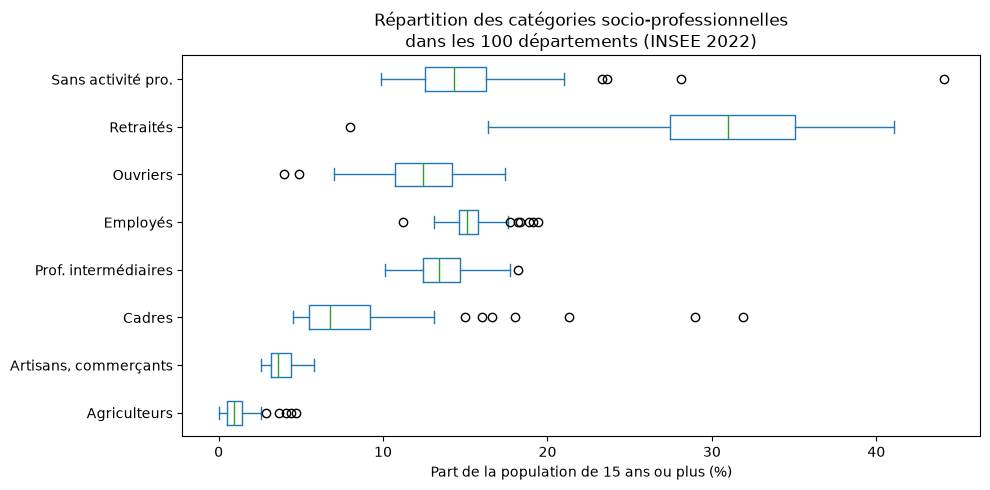

In [6]:
#Boxplot pour comparer les catégories entre départements

colonnes_pct = csp.columns[2:10]   

fig, ax = plt.subplots(figsize=(10, 5))
csp[colonnes_pct].plot(kind='box', vert=False, ax=ax)

ax.set_yticklabels(['Agriculteurs', 'Artisans, commerçants', 'Cadres',
                    'Prof. intermédiaires', 'Employés', 'Ouvriers',
                    'Retraités', 'Sans activité pro.'])
ax.set_xlabel('Part de la population de 15 ans ou plus (%)')
ax.set_title('Répartition des catégories socio-professionnelles\ndans les 100 départements (INSEE 2022)')
plt.tight_layout()
plt.show()

In [7]:
# Départements qui correspondent aux points isolés du boxplot: 
# Les 7 départements avec le plus de cadres
print(csp.nlargest(7, 'pct_cadres')[['nom_dep', 'pct_cadres']])

# Les 5 départements avec le plus de "sans activité"
print(csp.nlargest(5, 'pct_sans_activite')[['nom_dep', 'pct_sans_activite']])

# Les 5 départements avec le moins de retraités
print(csp.nsmallest(5, 'pct_retraites')[['nom_dep', 'pct_retraites']])

           nom_dep  pct_cadres
75           Paris        31.9
92  Hauts-de-Seine        29.0
78        Yvelines        21.3
94    Val-de-Marne        18.0
31   Haute-Garonne        16.6
69           Rhône        16.0
91         Essonne        15.0
              nom_dep  pct_sans_activite
98             Guyane               44.1
99         La Réunion               28.1
96         Guadeloupe               23.6
93  Seine-Saint-Denis               23.3
97         Martinique               21.0
              nom_dep  pct_retraites
98             Guyane            8.0
93  Seine-Saint-Denis           16.4
99         La Réunion           17.4
92     Hauts-de-Seine           18.7
75              Paris           18.8


Les retraités  et les cadres (concentrés en Île-de-France) sont les catégories qui varient le plus selon les départements.
Les retraités représentent un part de la population plus fragile face aux pathologies respiratoires.